In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('raw_data/Bank_Personal_Loan_Modelling.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (5000, 14)
Columns: ['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [3]:
print("Missing Values:\n", df.isnull().sum())
print("\nLoan Acceptance Distribution:")
print(df['Personal Loan'].value_counts())
print("\nStatistical Summary:")
df.describe()

Missing Values:
 ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

Loan Acceptance Distribution:
Personal Loan
0    4520
1     480
Name: count, dtype: int64

Statistical Summary:


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


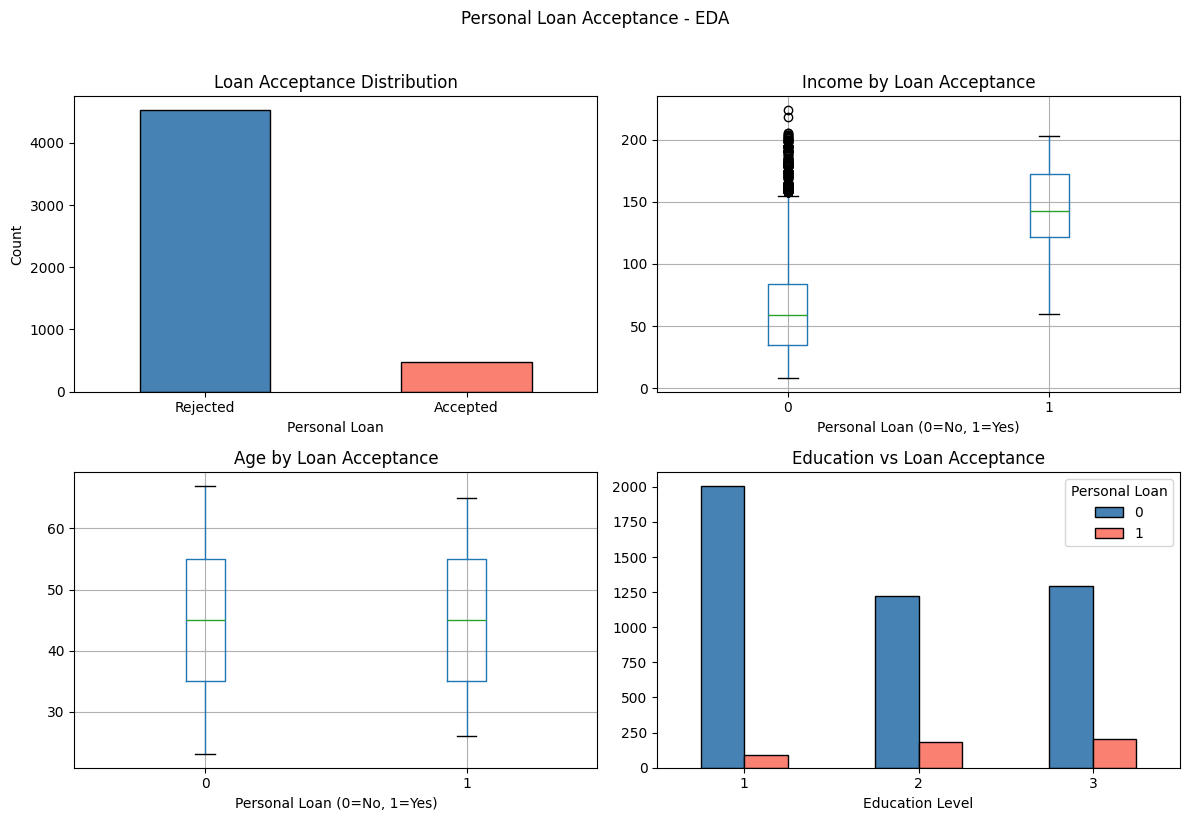

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Loan Acceptance Distribution
df['Personal Loan'].value_counts().plot(kind='bar', ax=axes[0,0],
                                         color=['steelblue','salmon'], 
                                         edgecolor='black')
axes[0,0].set_title('Loan Acceptance Distribution')
axes[0,0].set_xticklabels(['Rejected', 'Accepted'], rotation=0)
axes[0,0].set_ylabel('Count')

# Income vs Loan
df.boxplot(column='Income', by='Personal Loan', ax=axes[0,1])
axes[0,1].set_title('Income by Loan Acceptance')
axes[0,1].set_xlabel('Personal Loan (0=No, 1=Yes)')

# Age vs Loan
df.boxplot(column='Age', by='Personal Loan', ax=axes[1,0])
axes[1,0].set_title('Age by Loan Acceptance')
axes[1,0].set_xlabel('Personal Loan (0=No, 1=Yes)')

# Education vs Loan
df.groupby(['Education','Personal Loan']).size().unstack().plot(
    kind='bar', ax=axes[1,1], color=['steelblue','salmon'], edgecolor='black')
axes[1,1].set_title('Education vs Loan Acceptance')
axes[1,1].set_xlabel('Education Level')
axes[1,1].tick_params(rotation=0)

plt.suptitle('Personal Loan Acceptance - EDA', y=1.02)
plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150)
plt.show()

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Drop useless columns
df.drop(columns=['ID', 'ZIP Code'], inplace=True)

# Remove negative experience rows
df = df[df['Experience'] >= 0]

# Features and target
X = df.drop(columns=['Personal Loan'])
y = df['Personal Loan']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42)

# Train Decision Tree
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")
print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")

Model trained!
Train: 3958 samples, Test: 990 samples


Accuracy: 98.08%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       903
           1       0.90      0.87      0.89        87

    accuracy                           0.98       990
   macro avg       0.95      0.93      0.94       990
weighted avg       0.98      0.98      0.98       990



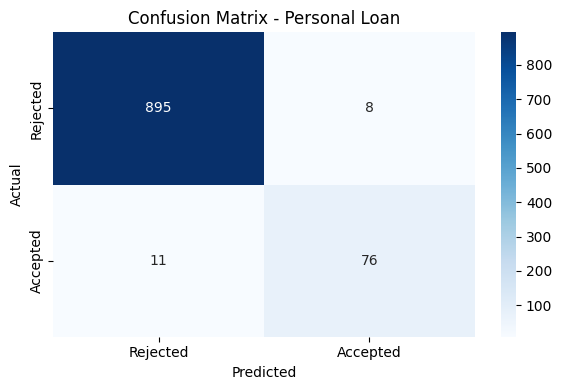

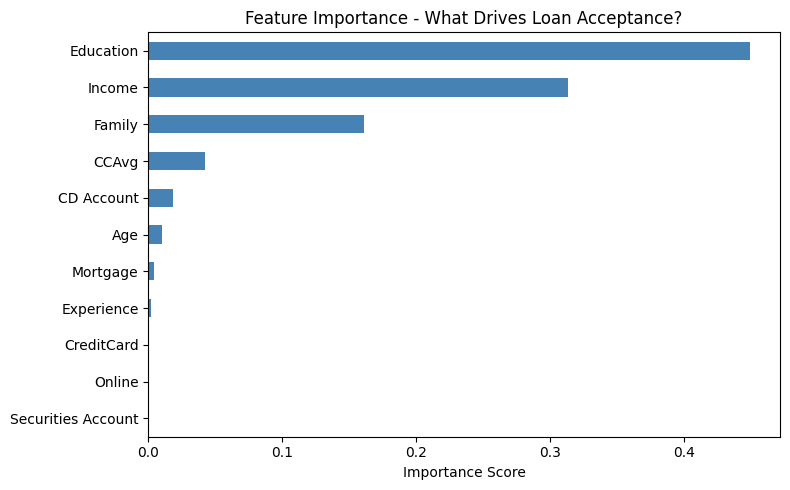

In [6]:
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Accepted'],
            yticklabels=['Rejected', 'Accepted'])
plt.title('Confusion Matrix - Personal Loan')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Feature Importance
feature_importance = pd.Series(model.feature_importances_,
                                index=X.columns)
feature_importance.sort_values().plot(kind='barh', figsize=(8,5),
                                       color='steelblue')
plt.title('Feature Importance - What Drives Loan Acceptance?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()